In [ ]:
import kagglehub
path = kagglehub.dataset_download("mohammadamireshraghi/blood-cell-cancer-all-4class")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cell-cancer-all-4class' dataset.
Path to dataset files: /kaggle/input/blood-cell-cancer-all-4class


In [ ]:
import tensorflow as tf
import numpy as np
import os

# Define image dimensions and batch size
IMG_HEIGHT = 224 # Changed to 224 for EfficientNetB0
IMG_WIDTH = 224  # Changed to 224 for EfficientNetB0
BATCH_SIZE = 32

# Get the path from the previous step
dataset_path = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"

print(f"Loading images from: {dataset_path}")

# Create training, validation, and test datasets
# First, create a combined train+validation set and a 'raw' validation set to be split into val and test
# We'll use 80% for training, 10% for validation, and 10% for testing.
# To achieve this with image_dataset_from_directory, we'll split 80/20 initially, then split the 20% (validation set) into 10% validation and 10% test.

# Calculate the total number of images (this assumes a flat directory structure or counts all files)
# A more robust way would be to count files within the dataset_path, or let image_dataset_from_directory do a dry run.
# For now, let's assume image_dataset_from_directory will figure out the total number of samples.

# Create the training dataset (e.g., 80% of total)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2, # 20% for validation and test combined initially
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Create the combined validation+test dataset (e.g., 20% of total)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Determine the number of validation and test samples from val_test_ds
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
if val_batches == -2: # -2 means unknown cardinality
    print("Warning: Cannot determine dataset cardinality directly. This might affect split accuracy.")
    print("Estimating dataset size by iterating through it. This might take a moment...")
    num_val_test_samples = 0
    for _ in val_test_ds:
        num_val_test_samples += BATCH_SIZE # Approximate count
    print(f"Estimated total samples in val_test_ds: {num_val_test_samples}")
    num_val_test_samples_per_batch = num_val_test_samples // BATCH_SIZE
else:
    num_val_test_samples_per_batch = val_batches

# Split the combined validation+test dataset into validation and test sets (e.g., 10% each)
# Assuming we want to split val_test_ds into two halves for val and test
num_val_samples_for_final_val = num_val_test_samples_per_batch // 2

validation_ds = val_test_ds.take(num_val_samples_for_final_val)
test_ds = val_test_ds.skip(num_val_samples_for_final_val)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Define a data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

# Create a preprocessing function that rescales pixel values from [0, 255] to [0, 1]
def preprocess(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

# Apply the data augmentation to the training dataset
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

# Apply the preprocessing function to all datasets
train_ds_preprocessed = augmented_train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
validation_ds_preprocessed = validation_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Configure the datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = train_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds_final = validation_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared: train_ds_final, validation_ds_final, test_ds_final")

Loading images from: /kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]
Found 3242 files belonging to 4 classes.
Using 2594 files for training.
Found 3242 files belonging to 4 classes.
Using 648 files for validation.
Number of training batches: 82
Number of validation batches: 10
Number of test batches: 11
Datasets prepared: train_ds_final, validation_ds_final, test_ds_final


In [ ]:
print("Installing KerasTuner...")
!pip install keras-tuner
print("KerasTuner installed.")

Installing KerasTuner...
KerasTuner installed.


In [ ]:
import keras_tuner as kt
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf
from tensorflow.keras import layers, models # Import layers and models

# Redefine IMG_SHAPE based on the updated IMG_HEIGHT and IMG_WIDTH
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# Define the number of classes based on dataset info (4 classes identified)
num_classes = 4

# Define the build_model function for KerasTuner
def build_model(hp):
    base_model_ht = EfficientNetB0(input_shape=IMG_SHAPE,
                                include_top=False,
                                weights='imagenet')

    # Enable fine-tuning for the base model by default
    base_model_ht.trainable = True

    # Tune the number of layers to freeze in the base model
    # A value of 0 means all base model layers are trainable.
    # A value of len(base_model_ht.layers) means all base model layers are frozen.
    # EfficientNetB0 has ~230 layers. Max value should be less than the total number of layers.
    fine_tune_at = hp.Int('fine_tune_at', min_value=0, max_value=200, step=50, default=0) # Tune freezing up to 200 initial layers

    for layer in base_model_ht.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = base_model_ht(inputs, training=True) # Set training=True for fine-tuning
    x = layers.GlobalAveragePooling2D()(x)

    # Tune dropout rate
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_rate)(x)

    # Add an additional dense layer for more learning capacity in the head
    # Tune the number of units in the dense layer
    num_units = hp.Int('num_dense_units', min_value=128, max_value=512, step=128)
    x = layers.Dense(num_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x) # Another dropout after the new dense layer

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_ht = models.Model(inputs, outputs)

    # Tune learning rate for the optimizer. When fine-tuning, typically a smaller LR is used.
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]) # Smaller learning rates for fine-tuning

    model_ht.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model_ht

# Instantiate the KerasTuner RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, # Increased trials to explore more hyperparameters
    executions_per_trial=1, # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='efficientnet_fine_tuning' # Updated project name to reflect fine-tuning
)

# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True # Increased patience
)

print("Starting hyperparameter search with fine-tuning...")
# Start the hyperparameter search
tuner.search(
    train_ds_final,
    epochs=15, # Increased epochs for each trial to allow more learning
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Hyperparameter search completed.")

Trial 10 Complete [00h 02m 32s]
val_accuracy: 0.6937500238418579

Best val_accuracy So Far: 0.987500011920929
Total elapsed time: 01h 01m 46s
Hyperparameter search completed.


In [ ]:
print("Best hyperparameters found by KerasTuner:")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Learning rate: {best_hps.get('learning_rate')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")

Best hyperparameters found by KerasTuner:
Learning rate: 0.0001
Dropout rate: 0.4


In [ ]:
# Get the best model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Compile the best model (it's already compiled with the best learning rate from build_model)

# Define callbacks for training
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train the best model
print("Training the best model...")
history = best_model.fit(
    train_ds_final,
    epochs=30, # A reasonable number of epochs, early stopping will prevent overfitting
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Best model trained successfully.")

Training the best model...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 348 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 121s 699ms/step - accuracy: 0.9530 - loss: 0.1051 - val_accuracy: 0.9719 - val_loss: 0.0617
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9611 - loss: 0.0771 - val_accuracy: 0.9781 - val_loss: 0.0751
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9769 - loss: 0.0517 - val_accuracy: 0.9937 - val_loss: 0.0183
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9773 - loss: 0.0545 - val_accuracy: 0.9563 - val_loss: 0.1113
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9668 - loss: 0.0684 - val_accuracy: 0.8687 - val_loss: 0.2954
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9788 - loss: 0.0465 - val_accuracy: 0.9469 - val_loss: 0.1157
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9780 - loss: 0.0463 - val_accuracy: 0.9781 - val_loss: 0.0613
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9819 - loss: 0.0405 - val_accuracy: 0.9469 - val_loss:

In [ ]:
print("Evaluating the best model on the test set...")
loss, accuracy = best_model.evaluate(test_ds_final)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating the best model on the test set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 470ms/step - accuracy: 0.9878 - loss: 0.0246
Test Loss: 0.0246
Test Accuracy: 0.9878


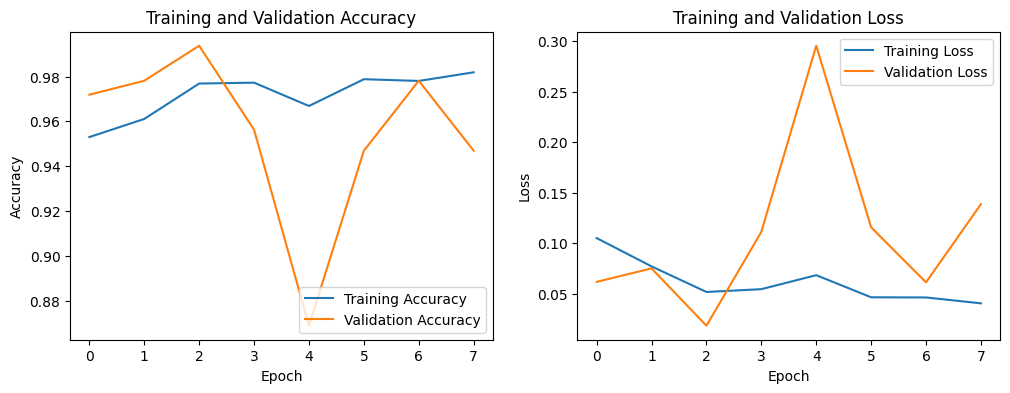

In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = history.epoch

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Generating Classification Report...
                         precision    recall  f1-score   support

                 Benign       0.96      0.98      0.97        55
      [Malignant] Pre-B       1.00      1.00      1.00        95
      [Malignant] Pro-B       0.99      1.00      0.99        73
[Malignant] early Pre-B       0.99      0.97      0.98       105

               accuracy                           0.99       328
              macro avg       0.99      0.99      0.99       328
           weighted avg       0.99      0.99      0.99       328

Generating Confusion Matrix...


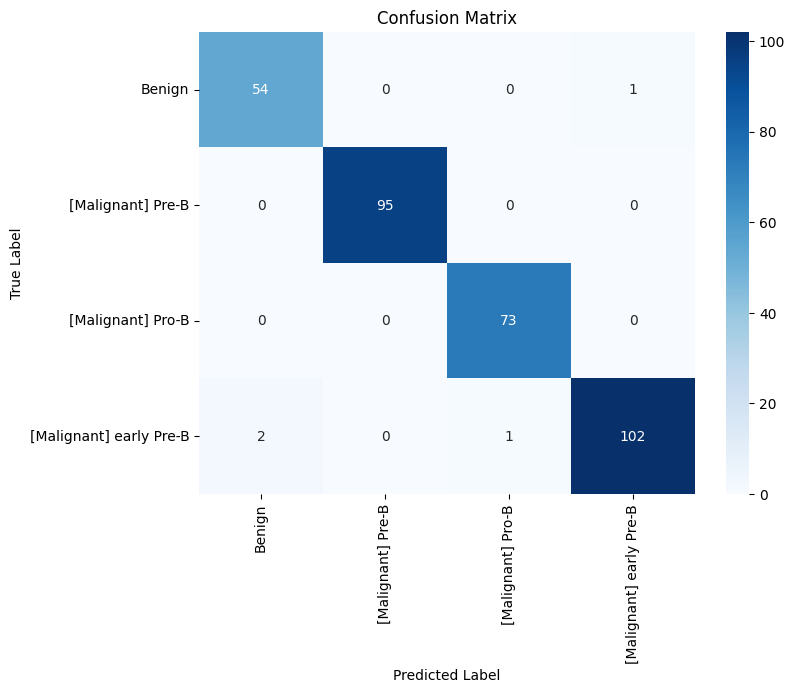

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds_final], axis=0)

# Get predictions from the model
y_pred_probs = best_model.predict(test_ds_final)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get class names from the training dataset
# Assuming train_ds was created using image_dataset_from_directory and retains class names
class_names = train_ds.class_names

print("Generating Classification Report...")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()